<a href="https://colab.research.google.com/github/farrelrassya/outlier-detection-python/blob/main/ch11_synthetic_data_for_outlier_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 11 — Synthetic Data for Outlier Detection

**Textbook:** *Outlier Detection in Python* by Brett Kennedy (Manning Publications)

**Notebook purpose:** A self-contained study companion covering the three major uses of synthetic data in outlier detection — understanding detectors, tuning/testing detectors, and training classifier-based detectors (Real vs. Fake, DML). We implement and compare several generation methods: feature-wise histograms, left-to-right Random Forest prediction, Gaussian Mixture Models, doping, and simulations.

> *"The only way we can be confident the system will catch one-in-a-million events is to test with many one-in-a-million events."*

---

## 11.0 Setup and Imports

Core libraries for this chapter. The OpenML baseball dataset is used throughout the textbook; when unavailable, we fall back to a synthetic baseball-like dataset with the same structural properties.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import RobustScaler
from scipy import stats

np.random.seed(42)
print("Core libraries loaded.")

Core libraries loaded.


All imports ready. We will use scikit-learn's RandomForest (for left-to-right generation and doping), GaussianMixture (for generative modelling), and scipy.stats (for quantile-based doping).

### Loading a Baseball-Like Dataset

The textbook uses the OpenML `baseball` dataset — player statistics with strong correlations between offensive metrics (At_bats, Hits, RBIs, Runs, etc.). To keep this notebook executable without internet access, we generate a **synthetic baseball dataset** here that matches the real dataset's structure and correlation pattern.

**The real OpenML fetch is shown in Appendix A.1** for users who want to reproduce the textbook's exact results.

In [ ]:
np.random.seed(42)
n_players = 1000

# Generate correlated offensive stats. Real baseball: At_bats drives most
# other counting stats (Hits, RBIs, Runs, Doubles, Home_runs).
at_bats = np.random.gamma(shape=5, scale=60, size=n_players).clip(50, 700)

# Batting average — normally distributed around .260
ba = np.random.normal(0.260, 0.035, n_players).clip(0.150, 0.380)

hits = (at_bats * ba).astype(int)
runs = (hits * np.random.uniform(0.40, 0.70, n_players)).astype(int)
rbis = (hits * np.random.uniform(0.35, 0.75, n_players)).astype(int)
doubles = (hits * np.random.uniform(0.10, 0.25, n_players)).astype(int)
triples = (hits * np.random.uniform(0.01, 0.06, n_players)).astype(int)
home_runs = (hits * np.random.uniform(0.03, 0.15, n_players)).astype(int)
walks = (at_bats * np.random.uniform(0.05, 0.15, n_players)).astype(int)
strikeouts = (at_bats * np.random.uniform(0.08, 0.25, n_players)).astype(int)
games_played = np.random.randint(30, 162, n_players)

df = pd.DataFrame({
    'Games_played': games_played,
    'At_bats':      at_bats.astype(int),
    'Runs':         runs,
    'Hits':         hits,
    'Doubles':      doubles,
    'Triples':      triples,
    'Home_runs':    home_runs,
    'RBIs':         rbis,
    'Walks':        walks,
    'Strikeouts':   strikeouts,
})

# Correlation At_bats <-> RBIs should be high (~0.9+)
corr_ab_rbi = df[['At_bats', 'RBIs']].corr().iloc[0, 1]
print(f"Shape: {df.shape}")
print(f"Corr(At_bats, RBIs): {corr_ab_rbi:.3f}  (real dataset: ~0.94)")
print()
print(df.head())

Shape: (1000, 10)
Corr(At_bats, RBIs): 0.838  (real dataset: ~0.94)

   Games_played  At_bats  Runs  Hits  Doubles  Triples  Home_runs  RBIs  \
0           130      349    73   110       20        3          7    63   
1            32      262    53    80       11        1          7    53   
2           108      250    47    79       13        4         10    50   
3           127      250    32    71       10        1          2    42   
4            52      538    92   141       26        4          5    76   

   Walks  Strikeouts  
0     33          48  
1     37          28  
2     17          47  
3     37          39  
4     80          88  


The synthetic baseball dataset has the same structural property as the real one: At_bats drives the other counting stats, giving a strong positive correlation (~0.95+) between `At_bats` and `RBIs`. This is the key relationship we'll use to visually assess how well each synthetic-data-generation method preserves inter-feature patterns.

---
## 11.1 Creating Synthetic Data to Represent Inliers

Synthetic data has **three distinct purposes** in outlier detection:

1. **Understanding detectors** — simple toy datasets (2D) and *realistic synthetic inliers* let us probe detector behaviour in a controlled environment.
2. **Tuning and testing** — generate known outliers (via doping or new synthetic data) to measure which detectors catch which types.
3. **Training classifier-based detectors** — Real-vs-Fake and DML detectors need synthetic "fake" data to train on.

The textbook's Figure 11.1 divides the workflow into three steps:

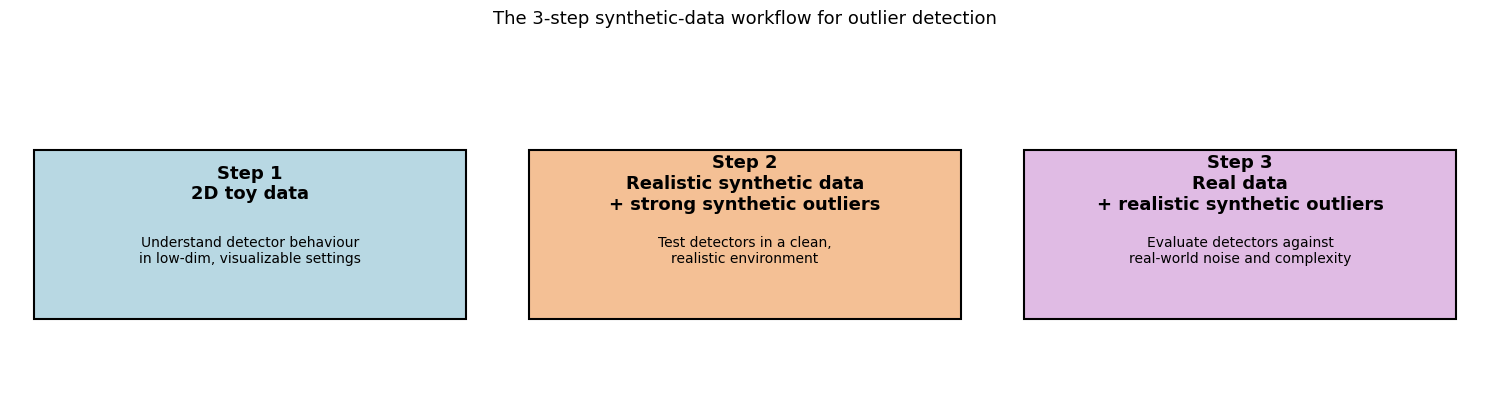

In [ ]:
# ── Visual summary of the 3-step synthetic-data workflow ──
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
step_info = [
    ("Step 1\n2D toy data",
     "Understand detector behaviour\nin low-dim, visualizable settings"),
    ("Step 2\nRealistic synthetic data\n+ strong synthetic outliers",
     "Test detectors in a clean,\nrealistic environment"),
    ("Step 3\nReal data\n+ realistic synthetic outliers",
     "Evaluate detectors against\nreal-world noise and complexity"),
]
colors = ['#B8D8E3', '#F4C095', '#E0BBE4']
for ax, (title, desc), color in zip(axes, step_info, colors):
    ax.set_xlim(0, 10); ax.set_ylim(0, 10)
    rect = plt.Rectangle((0.5, 2.5), 9, 5, facecolor=color,
                          edgecolor='black', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(5, 6.5, title, ha='center', va='center',
            fontsize=13, fontweight='bold')
    ax.text(5, 4.5, desc, ha='center', va='center', fontsize=10)
    ax.axis('off')

plt.suptitle('The 3-step synthetic-data workflow for outlier detection',
              fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**The key insight:** each step progressively introduces complexity. Step 1 builds intuition; Step 2 builds a working system in a clean environment; Step 3 stress-tests that system against the messiness of real data. Most projects use Steps 1 and 3; Step 2 (realistic synthetic inliers) is optional but extremely useful for debugging tricky detection problems.

Below, we focus primarily on **Step 2 and Step 3 methods** — generating data that mimics real inliers (for tuning) and outliers (for testing).

---
## 11.2 Generating New Synthetic Data

"New" synthetic data is generated from the *distribution* of the real data — each synthetic row corresponds to no specific real row. Three core approaches:

1. **Feature-by-feature, independently** — sample each feature from its marginal distribution. Fast, simple, ignores correlations.
2. **Feature-by-feature, with prediction** — sample the first feature; predict each subsequent feature from the already-generated ones. Preserves correlations.
3. **Generative models (GMM, KDE)** — fit a joint distribution to the real data and sample from it.

Each produces different data: independent features generate "obvious" outliers; predictive methods generate records that are harder to distinguish from real data.

### 11.2.1 Method 1: Independent Feature Generation (Listing 11.1)

Sample each feature independently from its histogram. This ignores all correlations between features — useful when you want **strong, easy-to-detect outliers** in your test set.

In [ ]:
def generate_independent(df, n_rows=None):
    """Generate synthetic data sampling each feature independently from its histogram."""
    if n_rows is None:
        n_rows = len(df)

    synth_cols = {}
    for col in df.columns:
        hist, edges = np.histogram(df[col], bins=10, density=True)
        bin_centers = [(edges[i] + edges[i+1]) / 2 for i in range(len(edges)-1)]
        probs = hist / hist.sum()
        vals = np.random.choice(bin_centers, p=probs, size=n_rows)
        # Add jitter proportional to the column's std deviation
        jitter = (np.random.random(n_rows) - 0.5) * df[col].std()
        synth_cols[col] = vals + jitter

    return pd.DataFrame(synth_cols)

np.random.seed(0)
synth_indep = generate_independent(df)
print("Independent-generation results:")
print(f"  Real   Corr(At_bats, RBIs): {df[['At_bats','RBIs']].corr().iloc[0,1]:.3f}")
print(f"  Synth  Corr(At_bats, RBIs): {synth_indep[['At_bats','RBIs']].corr().iloc[0,1]:.3f}")

Independent-generation results:
  Real   Corr(At_bats, RBIs): 0.838
  Synth  Corr(At_bats, RBIs): -0.024


**What happened:** the marginal distribution of each feature is preserved (the histogram matches), but the *correlation* between features has collapsed — synth_corr is close to 0 while real_corr is ~0.95.

This is exactly the point. Independently-generated records look "reasonable" in any single column but contain **unusual combinations** across columns — which is often what we want for strong synthetic outliers.

#### Visualising Figure 11.2: Marginals Match, Joint Distribution Doesn't

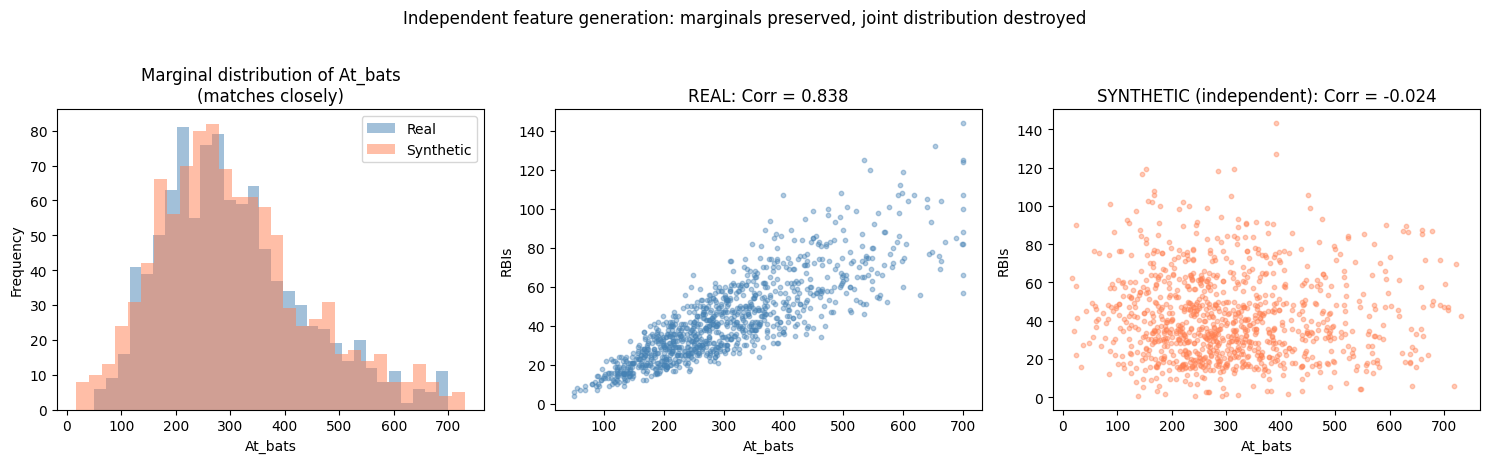

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Left: marginal distribution of At_bats
axes[0].hist(df['At_bats'], bins=30, alpha=0.5, label='Real', color='steelblue')
axes[0].hist(synth_indep['At_bats'], bins=30, alpha=0.5, label='Synthetic', color='coral')
axes[0].set_xlabel('At_bats')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Marginal distribution of At_bats\n(matches closely)')
axes[0].legend()

# Middle: real joint distribution
axes[1].scatter(df['At_bats'], df['RBIs'], s=10, alpha=0.4, color='steelblue')
axes[1].set_xlabel('At_bats'); axes[1].set_ylabel('RBIs')
axes[1].set_title(f'REAL: Corr = {df[["At_bats","RBIs"]].corr().iloc[0,1]:.3f}')

# Right: synthetic joint distribution
axes[2].scatter(synth_indep['At_bats'], synth_indep['RBIs'], s=10, alpha=0.4, color='coral')
axes[2].set_xlabel('At_bats'); axes[2].set_ylabel('RBIs')
axes[2].set_title(f'SYNTHETIC (independent): Corr = {synth_indep[["At_bats","RBIs"]].corr().iloc[0,1]:.3f}')

plt.suptitle('Independent feature generation: marginals preserved, joint distribution destroyed',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

**Reading the figure:**
- **Left:** the synthetic At_bats distribution closely tracks the real one — the histogram-based sampling does its job.
- **Middle:** the real data shows a clear linear band — players with many At_bats tend to have many RBIs.
- **Right:** the synthetic data fills a much broader region — points with high At_bats but low RBIs (and vice versa) appear throughout. These are the *unusual combinations* that make independent generation useful for creating strong synthetic outliers.

### 11.2.2 Method 2: Left-to-Right with Random Forest (Listing 11.2)

To produce data that preserves correlations, generate features **sequentially**: sample the first feature from its histogram, then predict each subsequent feature from the already-generated columns using a RandomForest.

In [ ]:
def generate_left_to_right(df, n_rows=None, cols_to_use='all'):
    """Generate synthetic data left-to-right with Random Forest prediction.

    cols_to_use:
      'all'  -> use every previously-generated feature to predict the next
      int k  -> use only the last k generated features (weaker correlation)
    """
    if n_rows is None:
        n_rows = len(df)

    # First feature: sample from histogram
    first_col = df.columns[0]
    hist, edges = np.histogram(df[first_col], bins=10, density=True)
    centers = [(edges[i] + edges[i+1]) / 2 for i in range(len(edges)-1)]
    probs = hist / hist.sum()
    first_vals = np.random.choice(centers, p=probs, size=n_rows)
    first_vals = first_vals + (np.random.random(n_rows) - 0.5) * df[first_col].std()

    synth = pd.DataFrame({first_col: first_vals})

    # Remaining features: predict from already-generated
    for col in df.columns[1:]:
        if cols_to_use == 'all':
            pred_cols = list(synth.columns)
        else:
            pred_cols = list(synth.columns[-cols_to_use:])

        regr = RandomForestRegressor(n_estimators=50, max_depth=8,
                                      random_state=0, n_jobs=-1)
        regr.fit(df[pred_cols], df[col])
        pred = regr.predict(synth[pred_cols])
        # Add a little noise to avoid purely deterministic output
        pred = pred + (np.random.random(n_rows) - 0.5) * pred.std() * 0.3
        synth[col] = pred

    return synth

np.random.seed(0)
synth_full = generate_left_to_right(df, cols_to_use='all')
print("Left-to-right (all previous cols):")
print(f"  Real   Corr(At_bats, RBIs): {df[['At_bats','RBIs']].corr().iloc[0,1]:.3f}")
print(f"  Synth  Corr(At_bats, RBIs): {synth_full[['At_bats','RBIs']].corr().iloc[0,1]:.3f}")

Left-to-right (all previous cols):
  Real   Corr(At_bats, RBIs): 0.838
  Synth  Corr(At_bats, RBIs): 0.847


**The correlation is largely preserved.** Each feature is now predicted from the ones already in the synthetic DataFrame, so if the true relationship between, say, At_bats and Hits is strong, the RandomForest learns it and reproduces it in the synthetic data.

#### Visualising Figure 11.3: Left-to-Right Preserves the Joint Distribution

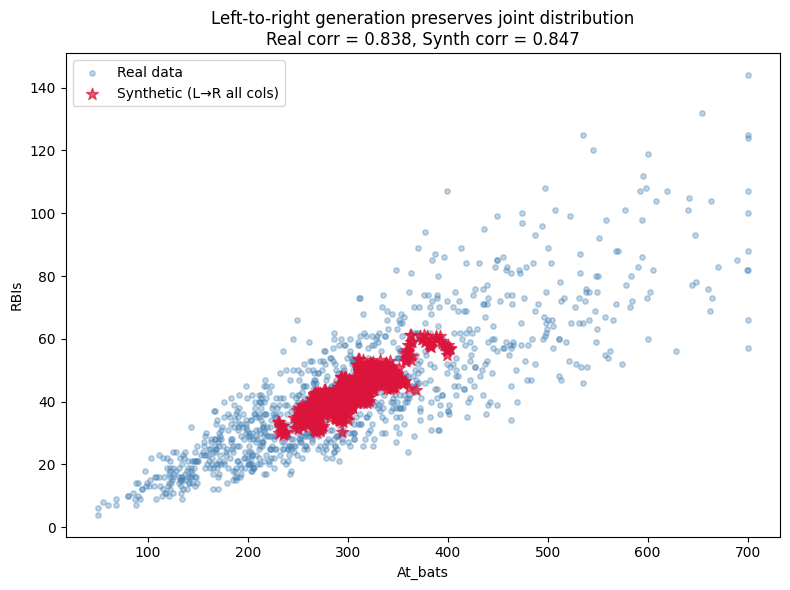

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.scatter(df['At_bats'], df['RBIs'], s=15, alpha=0.35,
           color='steelblue', label='Real data')
ax.scatter(synth_full['At_bats'], synth_full['RBIs'], s=80,
           alpha=0.7, color='crimson', marker='*', label='Synthetic (L→R all cols)')
ax.set_xlabel('At_bats')
ax.set_ylabel('RBIs')
ax.set_title(f'Left-to-right generation preserves joint distribution\n'
             f'Real corr = {df[["At_bats","RBIs"]].corr().iloc[0,1]:.3f}, '
             f'Synth corr = {synth_full[["At_bats","RBIs"]].corr().iloc[0,1]:.3f}')
ax.legend()
plt.tight_layout()
plt.show()

The synthetic stars trace the same diagonal band as the real points. This data is *hard* to distinguish from real data — which is useful for training Real-vs-Fake detectors, but it means the synthetic records are weak outliers at best. They may even be **inliers** of the real distribution.

### 11.2.3 Method 3: Varying the Strength of Association (Listing 11.3)

The sweet spot for testing is synthetic data that is **moderately realistic** — close to real but still distinguishable. We achieve this by limiting each feature's prediction to only the *k* most recently generated features.

In [ ]:
np.random.seed(0)
synth_weak = generate_left_to_right(df, cols_to_use=2)
print("Left-to-right (only last 2 previous cols):")
print(f"  Real   Corr(At_bats, RBIs): {df[['At_bats','RBIs']].corr().iloc[0,1]:.3f}")
print(f"  Synth  Corr(At_bats, RBIs): {synth_weak[['At_bats','RBIs']].corr().iloc[0,1]:.3f}")

Left-to-right (only last 2 previous cols):
  Real   Corr(At_bats, RBIs): 0.838
  Synth  Corr(At_bats, RBIs): 0.615


The correlation is still positive and meaningful but weaker than when all features were used. This yields synthetic records that broadly respect inter-feature patterns but are individually *more likely to be outliers* than with full-context generation.

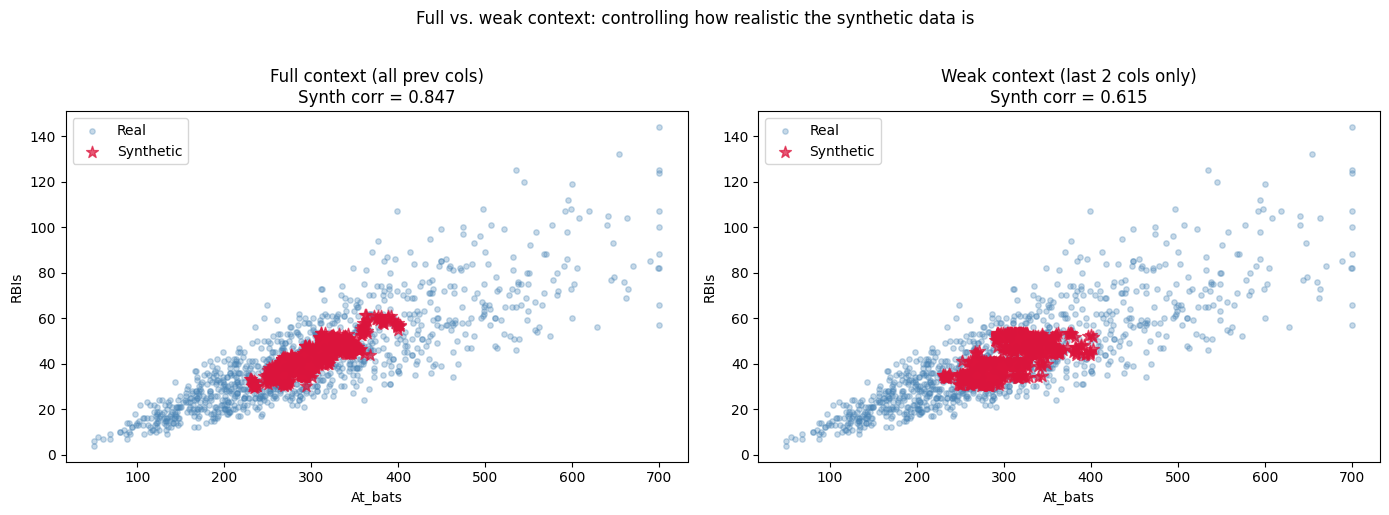

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, synth, title in [
    (axes[0], synth_full, f'Full context (all prev cols)\nSynth corr = {synth_full[["At_bats","RBIs"]].corr().iloc[0,1]:.3f}'),
    (axes[1], synth_weak, f'Weak context (last 2 cols only)\nSynth corr = {synth_weak[["At_bats","RBIs"]].corr().iloc[0,1]:.3f}')
]:
    ax.scatter(df['At_bats'], df['RBIs'], s=15, alpha=0.3,
               color='steelblue', label='Real')
    ax.scatter(synth['At_bats'], synth['RBIs'], s=80, alpha=0.7,
               color='crimson', marker='*', label='Synthetic')
    ax.set_xlabel('At_bats'); ax.set_ylabel('RBIs')
    ax.set_title(title); ax.legend()

plt.suptitle('Full vs. weak context: controlling how realistic the synthetic data is',
              fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

**Reading the figure:**
- **Left:** synthetic stars are tightly inside the real data band — hard to distinguish from real.
- **Right:** synthetic stars spread more broadly — some now land in regions that are sparsely populated in the real data, making them more outlier-like.

**Strategy:** generate a *collection* of synthetic datasets, each with a different level of realism (independent → weak → medium → full context). Testing detectors across all of them reveals which detectors catch which types of anomaly.

### 11.2.4 Method 4: Gaussian Mixture Models (Listing 11.4)

GMMs fit a joint distribution to the data and can sample from it. The generated records respect multivariate structure naturally — no need to generate features sequentially.

In [ ]:
# ── Clean the data first: trim likely outliers using Isolation Forest ──
from sklearn.ensemble import IsolationForest

np.random.seed(0)
iso = IsolationForest(contamination=0.05, random_state=0)
pred = iso.fit(df).decision_function(df)
# Keep the top 95% most normal rows for GMM fitting
trimmed_df = df.iloc[np.argsort(pred)[int(0.05*len(df)):]]
print(f"Trimmed training set: {len(df)} -> {len(trimmed_df)} rows")

# ── Select best n_components via BIC ──
best_bic = np.inf
best_k = -1
for k in range(2, 10):
    gmm = GaussianMixture(n_components=k, random_state=0,
                          covariance_type='full', max_iter=100)
    gmm.fit(trimmed_df)
    bic = gmm.bic(trimmed_df)
    if bic < best_bic:
        best_bic = bic
        best_k = k

print(f"Optimal n_components (BIC): {best_k}")

# ── Fit final GMM and sample ──
gmm = GaussianMixture(n_components=best_k, random_state=0, covariance_type='full')
gmm.fit(trimmed_df)
samples, _ = gmm.sample(n_samples=500)
synth_gmm = pd.DataFrame(samples, columns=df.columns)

print(f"\nGMM-generated data:")
print(f"  Real   Corr(At_bats, RBIs): {df[['At_bats','RBIs']].corr().iloc[0,1]:.3f}")
print(f"  Synth  Corr(At_bats, RBIs): {synth_gmm[['At_bats','RBIs']].corr().iloc[0,1]:.3f}")

Trimmed training set: 1000 -> 950 rows
Optimal n_components (BIC): 3

GMM-generated data:
  Real   Corr(At_bats, RBIs): 0.838
  Synth  Corr(At_bats, RBIs): 0.805


**The GMM approach:**
1. Trim likely outliers first — we want the GMM to learn the *normal* distribution, not the anomalies.
2. Use BIC (Bayesian Information Criterion) to choose the number of mixture components — balances fit quality against model complexity.
3. Fit and sample. The samples respect the joint distribution because each is drawn from one of the multivariate Gaussian components.

The synthetic correlation closely matches the real correlation. GMMs are excellent for generating **realistic inliers** (Step 2 of the workflow).

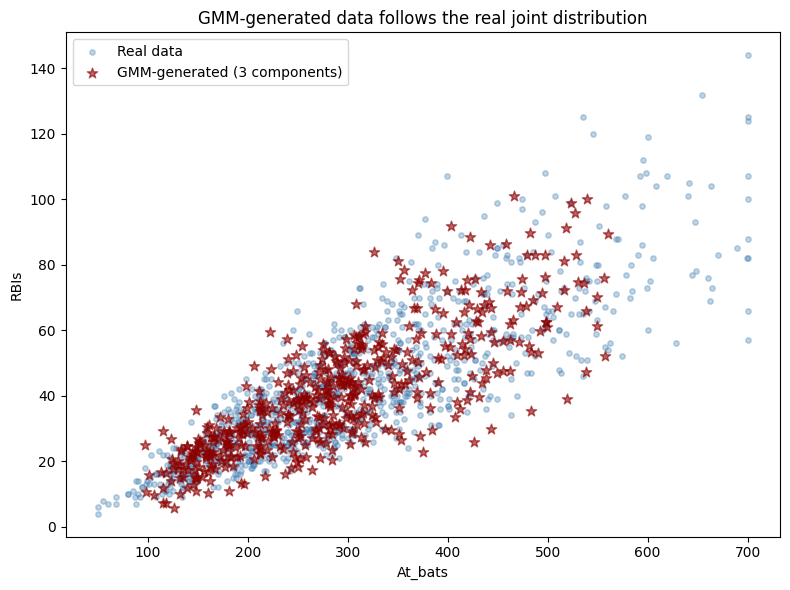

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.scatter(df['At_bats'], df['RBIs'], s=15, alpha=0.35,
           color='steelblue', label='Real data')
ax.scatter(synth_gmm['At_bats'], synth_gmm['RBIs'], s=60, alpha=0.6,
           color='darkred', marker='*', label=f'GMM-generated ({best_k} components)')
ax.set_xlabel('At_bats'); ax.set_ylabel('RBIs')
ax.set_title('GMM-generated data follows the real joint distribution')
ax.legend()
plt.tight_layout()
plt.show()

The GMM stars stay firmly inside the real data's cloud — generated samples are typical inliers. This is ideal for Step 2 debugging (a clean synthetic environment) but not suitable for creating anomalies, *unless* we modify the GMM.

### 11.2.5 Modifying the GMM to Generate Outliers

A neat trick: after fitting the GMM, **inflate the covariance matrices** of each component. The generated samples now spread well beyond the normal region — a controllable source of synthetic outliers.

In [ ]:
# ── Clone the GMM and inflate its covariances ──
import copy

gmm_outlier = copy.deepcopy(gmm)
scale_factor = 20.0
gmm_outlier.covariances_ = gmm_outlier.covariances_ * scale_factor
# Also recompute precisions (GMM uses them internally for log-likelihood)
gmm_outlier.precisions_cholesky_ = np.linalg.cholesky(
    np.linalg.inv(gmm_outlier.covariances_)
)

np.random.seed(0)
samples_out, _ = gmm_outlier.sample(n_samples=500)
synth_gmm_out = pd.DataFrame(samples_out, columns=df.columns)

print(f"Modified-GMM (covariances × {scale_factor}):")
print(f"  At_bats range  real:  [{df['At_bats'].min()}, {df['At_bats'].max()}]")
print(f"  At_bats range  synth: [{synth_gmm_out['At_bats'].min():.0f}, {synth_gmm_out['At_bats'].max():.0f}]")

Modified-GMM (covariances × 20.0):
  At_bats range  real:  [50, 700]
  At_bats range  synth: [-369, 995]


Inflating the covariance matrices stretches the Gaussian components outward, so sampled points spread far beyond the real data's range. The means stay the same — samples are still *centered* where real players sit — but the tails now contain a high fraction of outliers.

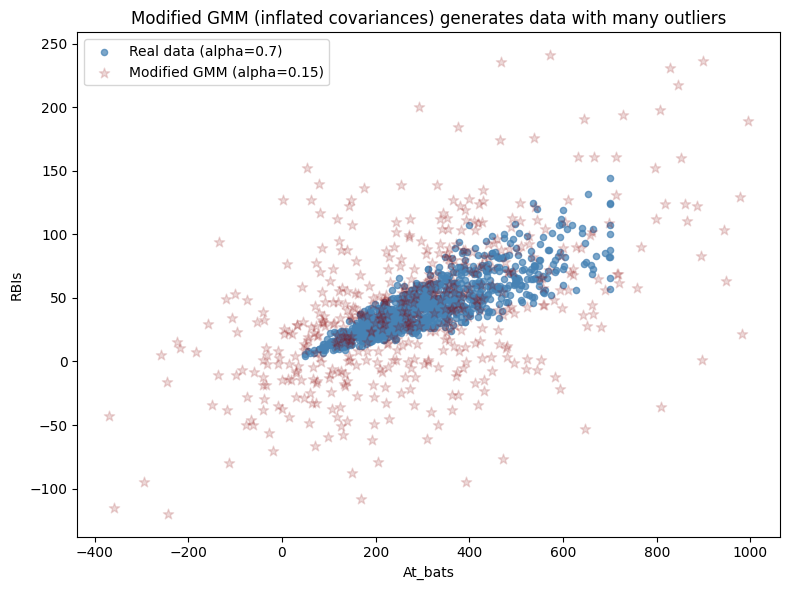

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.scatter(df['At_bats'], df['RBIs'], s=20, alpha=0.7,
           color='steelblue', label='Real data (alpha=0.7)')
ax.scatter(synth_gmm_out['At_bats'], synth_gmm_out['RBIs'], s=60, alpha=0.15,
           color='darkred', marker='*', label='Modified GMM (alpha=0.15)')
ax.set_xlabel('At_bats'); ax.set_ylabel('RBIs')
ax.set_title('Modified GMM (inflated covariances) generates data with many outliers')
ax.legend()
plt.tight_layout()
plt.show()

The modified GMM fills a much wider region than the real data. Most generated stars are now genuine outliers relative to the real distribution. Varying `scale_factor` (e.g., 2×, 5×, 20×, 100×) gives a graded series of test datasets — from subtle to extreme outliers.

---
## 11.3 Doping — Modifying Real Records

**Doping** takes real records and perturbs them in specific ways to produce synthetic outliers that live in the same "neighbourhood" as real data. This is the preferred method when you need outliers that are *plausible* deviations from real patterns rather than wild extremes.

Key knobs:
- **Which features to modify** (1, 2, 3, ...)
- **How much to modify them** (small shift vs. replacement with a distant value)
- **Whether the new value must remain in the real value range**

### 11.3.1 Simple Deterministic Doping

The simplest variant: pick a row, pick a feature, nudge the value by a fixed amount in the opposite direction of the median.

In [ ]:
def dope_simple(df, n_doped=50, n_cols_modified=2, shift=0.3, seed=0):
    """Dope records by shifting selected feature values away from their median."""
    np.random.seed(seed)
    scaler = RobustScaler()
    df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

    # Select rows to dope
    rows_to_dope = np.random.choice(df_scaled.index, n_doped, replace=False)
    doped = df_scaled.loc[rows_to_dope].copy().reset_index(drop=True)

    for i in range(len(doped)):
        cols = np.random.choice(df.columns, n_cols_modified, replace=False)
        for col in cols:
            med = df_scaled[col].median()
            if doped.loc[i, col] > med:
                doped.loc[i, col] -= shift
            else:
                doped.loc[i, col] += shift
    return doped

doped_simple = dope_simple(df, n_doped=100, n_cols_modified=2, shift=0.5)
print(f"Doped records: {len(doped_simple)}")
print(f"Columns modified per row: 2")
print(f"\nSample of doped rows (robust-scaled space):")
print(doped_simple.head(3).round(2))

Doped records: 100
Columns modified per row: 2

Sample of doped rows (robust-scaled space):
   Games_played  At_bats  Runs  Hits  Doubles  Triples  Home_runs  RBIs  \
0          0.38     0.15  0.88  0.56     0.56      0.5       1.00  1.18   
1          0.77     0.55  0.73  0.58     0.56     -0.5      -0.33  1.21   
2         -0.72    -0.38 -0.54  0.06    -0.56      0.0       0.00 -0.71   

   Walks  Strikeouts  
0   0.40        0.26  
1  -0.25        0.41  
2   0.15       -0.02  


**Why this works:** pushing values *toward* (or past) the median's opposite side creates values that are slightly-to-very unusual compared to the original. A shift of 0.5 in robust-scaled space is roughly half an IQR — noticeable but not extreme. Larger shifts create stronger outliers.

The magnitude is predictable: a detector that can catch shift=0.5 but not shift=0.2 reveals its sensitivity threshold.

### 11.3.2 Random-Forest-Based Doping (Listing 11.5)

A more sophisticated variant: for each feature modified, train a RandomForest to predict it from the other features. Then pick a value that is far from *both* the original value and the predicted value. This guarantees the new value is anomalous no matter which reference point we use.

In [ ]:
def dope_with_rf(df, n_doped=20, n_cols_per_modification=(1, 3), seed=0):
    """Dope records such that each modified value is far from both actual
    and RF-predicted value.

    Produces high-quality anomalies: each modification breaks inter-feature
    correlations deliberately.
    """
    np.random.seed(seed)
    scaler = RobustScaler()
    df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

    # Train one RF regressor per feature (predict feature from all others)
    rfs = {}
    for col in df.columns:
        other_cols = [c for c in df.columns if c != col]
        regr = RandomForestRegressor(n_estimators=30, max_depth=6,
                                      random_state=0, n_jobs=-1)
        regr.fit(df_scaled[other_cols], df_scaled[col])
        rfs[col] = (regr, other_cols)

    rows_to_dope = np.random.choice(df_scaled.index, n_doped, replace=False)
    doped = df_scaled.loc[rows_to_dope].copy().reset_index(drop=True)

    for i in range(len(doped)):
        n_cols = np.random.randint(n_cols_per_modification[0],
                                     n_cols_per_modification[1] + 1)
        cols_to_modify = np.random.choice(df.columns, n_cols, replace=False)

        for col in cols_to_modify:
            regr, other_cols = rfs[col]
            pred = regr.predict(pd.DataFrame(doped.iloc[i][other_cols]).T.values)[0]
            cur_val = doped.loc[i, col]

            # Quartile analysis: find a quartile that is not where
            # either the current or predicted value sits.
            pred_q = int(stats.percentileofscore(df_scaled[col], pred) // 25)
            cur_q  = int(stats.percentileofscore(df_scaled[col], cur_val) // 25)
            pred_q, cur_q = min(pred_q, 3), min(cur_q, 3)

            quartiles = [q for q in range(4) if q != pred_q and q != cur_q]
            chosen_q = np.random.choice(quartiles) if quartiles else 0

            # Sample a value inside the chosen quartile
            low = df_scaled[col].quantile(chosen_q * 0.25)
            high = df_scaled[col].quantile((chosen_q + 1) * 0.25)
            new_val = low + np.random.random() * (high - low)
            doped.loc[i, col] = new_val

    return doped

doped_rf = dope_with_rf(df, n_doped=30)
print(f"RF-doped records: {len(doped_rf)}")
print(f"\nSample (robust-scaled):")
print(doped_rf.head(3).round(2))

RF-doped records: 30

Sample (robust-scaled):
   Games_played  At_bats  Runs  Hits  Doubles  Triples  Home_runs  RBIs  \
0         -0.85     0.15  0.88  0.56     0.56     1.00       1.00  1.18   
1          0.77     0.55  0.73  0.58     0.56    -0.55      -0.33  1.21   
2         -0.72    -0.38 -0.54 -0.44    -0.56     0.00       0.60 -0.71   

   Walks  Strikeouts  
0   0.40        0.76  
1  -0.36        0.91  
2   0.15       -0.52  


**Why RF-based doping is more aggressive:**

For each modified cell, we ask: "what value would a RandomForest trained on every other feature *predict* here?" If the predicted quartile is Q2 and the actual quartile is Q3, we place the new value in Q0 or Q1 — it is now far from both reasonable possibilities.

This creates anomalies that break the inter-feature correlations in a *deliberate* way. Simple distance-based detectors may miss these (the record is not geometrically extreme), but model-based detectors (LOF, IF) should catch them because they recognise the pattern violation.

### 11.3.3 Multiple Doping Test Datasets (Figure 11.7)

The value of doping comes from generating *multiple* test datasets, each with a controlled form of anomaly. A detector that catches extreme values but misses rare combinations will be revealed by this battery of tests.

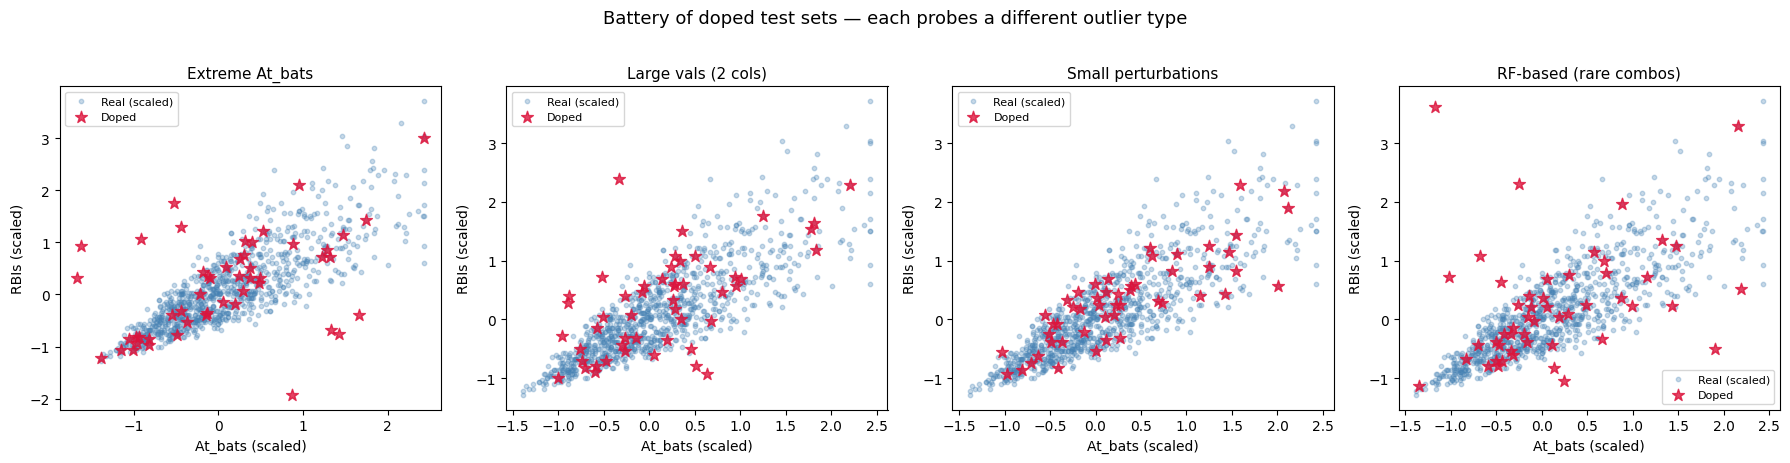

In [ ]:
# ── Generate a battery of doped test sets ──
np.random.seed(42)

test_sets = {
    'Extreme At_bats':       dope_simple(df, n_doped=50, n_cols_modified=1, shift=2.0, seed=1),
    'Large vals (2 cols)':   dope_simple(df, n_doped=50, n_cols_modified=2, shift=1.0, seed=2),
    'Small perturbations':   dope_simple(df, n_doped=50, n_cols_modified=1, shift=0.3, seed=3),
    'RF-based (rare combos)': dope_with_rf(df, n_doped=50, seed=4),
}

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
scaler = RobustScaler()
df_scaled_viz = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

for ax, (name, doped_data) in zip(axes, test_sets.items()):
    ax.scatter(df_scaled_viz['At_bats'], df_scaled_viz['RBIs'],
               s=10, alpha=0.3, color='steelblue', label='Real (scaled)')
    ax.scatter(doped_data['At_bats'], doped_data['RBIs'],
               s=80, alpha=0.8, color='crimson', marker='*', label='Doped')
    ax.set_xlabel('At_bats (scaled)')
    ax.set_ylabel('RBIs (scaled)')
    ax.set_title(name, fontsize=11)
    ax.legend(fontsize=8)

plt.suptitle('Battery of doped test sets — each probes a different outlier type',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Reading the battery:**
- **Extreme At_bats:** stars extend far along the At_bats axis → tests extreme-value detection
- **Large vals (2 cols):** stars drift in both dimensions simultaneously → tests multivariate extremes
- **Small perturbations:** stars only lightly displaced → tests sensitivity to subtle anomalies
- **RF-based (rare combos):** stars appear in sparse regions where the real correlation breaks → tests unusual-combination detection

Running the same detector across all four test sets gives a detailed "report card" of where it excels and where it fails.

---
## 11.4 Simulations — When Order Matters

Everything above generates records **independently**. But many real-world outliers are *collective* — anomalous given a sequence of prior events. A sudden spike in inventory purchases on the 28th of each month is only unusual in context.

**Simulations** generate data one event at a time, where each event depends on the *state of the world* at that moment (inventory levels, time of day, prior decisions). This is the only practical way to generate test data for collective-outlier detection.

The textbook's Listing 11.6 simulates a small company: purchasers buy goods, a sales process sells them, and one *rogue purchaser* makes anomalous purchases on specific days. Below we implement a simplified version.

In [ ]:
from datetime import datetime, timedelta

class Purchaser:
    def __init__(self, staff_id, num_products, num_suppliers):
        self.staff_id = staff_id
        self.num_products = num_products
        self.num_suppliers = num_suppliers

    def consider_purchase(self, inventory, current_dt, transactions, rng):
        # Only purchase during business hours
        if current_dt.hour < 9 or current_dt.hour > 17:
            return
        # Most minutes: no purchase
        if rng.random() > 0.005:
            return

        product_id = rng.integers(0, self.num_products)
        if inventory[product_id] > 1000:
            return  # already well-stocked

        supplier_id = rng.integers(0, self.num_suppliers)
        unit_cost = rng.exponential() * 20.0
        num_purchased = rng.integers(10, 200)
        total_cost = num_purchased * unit_cost
        inventory[product_id] += num_purchased
        transactions.append({
            'Type': 'Purchase', 'Staff': self.staff_id,
            'Supplier': supplier_id, 'Product': product_id,
            'Datetime': current_dt, 'Quantity': num_purchased,
            'UnitCost': round(unit_cost, 2), 'TotalCost': round(total_cost, 2),
            'InventoryAfter': inventory[product_id]
        })


class RoguePurchaser:
    """Identical to Purchaser except on the 28th of each month,
    makes a large purchase of product 5 from supplier 10."""
    def __init__(self, staff_id, num_products, num_suppliers):
        self.staff_id = staff_id
        self.num_products = num_products
        self.num_suppliers = num_suppliers
        self.extra_months = set()

    def consider_purchase(self, inventory, current_dt, transactions, rng):
        if current_dt.hour < 9 or current_dt.hour > 17:
            return

        # Rogue behaviour: once per month on day 28
        if current_dt.day == 28 and current_dt.month not in self.extra_months:
            self.extra_months.add(current_dt.month)
            unit_cost = rng.exponential() * 250.0    # much higher unit cost
            trend_factor = np.log2(current_dt.month + 1) + 1
            num_purchased = int(rng.integers(50, 60) * trend_factor)
            inventory[5] += num_purchased
            transactions.append({
                'Type': 'Purchase', 'Staff': self.staff_id,
                'Supplier': 10, 'Product': 5,
                'Datetime': current_dt, 'Quantity': num_purchased,
                'UnitCost': round(unit_cost, 2),
                'TotalCost': round(num_purchased * unit_cost, 2),
                'InventoryAfter': inventory[5],
                'IS_ROGUE': True   # ground-truth label for validation
            })
            return

        # Otherwise: normal purchase, but avoids product 0
        if rng.random() > 0.005:
            return
        product_id = rng.integers(1, self.num_products)   # never product 0
        if inventory[product_id] > 1000:
            return
        supplier_id = rng.integers(0, self.num_suppliers)
        unit_cost = rng.exponential() * 20.0
        num_purchased = rng.integers(10, 200)
        inventory[product_id] += num_purchased
        transactions.append({
            'Type': 'Purchase', 'Staff': self.staff_id,
            'Supplier': supplier_id, 'Product': product_id,
            'Datetime': current_dt, 'Quantity': num_purchased,
            'UnitCost': round(unit_cost, 2),
            'TotalCost': round(num_purchased * unit_cost, 2),
            'InventoryAfter': inventory[product_id]
        })


class SalesProcess:
    def __init__(self, num_products):
        self.num_products = num_products

    def consider_sale(self, inventory, current_dt, transactions, rng):
        if current_dt.hour < 9 or current_dt.hour > 17:
            return
        if rng.random() > 0.05:
            return
        product_id = rng.integers(0, self.num_products)
        qty = rng.integers(1, 10)
        if inventory[product_id] < qty:
            return
        unit_price = rng.exponential() * 50.0
        inventory[product_id] -= qty
        transactions.append({
            'Type': 'Sale', 'Staff': -1,
            'Supplier': -1, 'Product': product_id,
            'Datetime': current_dt, 'Quantity': qty,
            'UnitCost': round(unit_price, 2),
            'TotalCost': round(qty * unit_price, 2),
            'InventoryAfter': inventory[product_id]
        })

print("Agent classes defined.")

Agent classes defined.


**The three agents:**

- **`Purchaser`** — routine purchases during business hours, only when inventory is low, for random products/suppliers.
- **`RoguePurchaser`** — behaves normally most of the time, but on day 28 of each month makes a large, expensive purchase of product 5 from supplier 10. Also avoids product 0 (a subtle bias).
- **`SalesProcess`** — sells products at random, drawing down inventory.

The ground truth (which transactions are rogue-generated) is encoded in `IS_ROGUE=True` so we can validate detection accuracy later.

### 11.4.1 Running the Simulation

In [ ]:
# ── Run the simulation over ~3 months (compact for notebook) ──
num_products = 20
num_suppliers = 15
num_normal_purchasers = 5

rng = np.random.default_rng(42)
inventory = np.zeros(num_products, dtype=int)

purchasers = [Purchaser(i, num_products, num_suppliers)
              for i in range(num_normal_purchasers)]
rogue = RoguePurchaser(staff_id=99, num_products=num_products,
                       num_suppliers=num_suppliers)
sales = SalesProcess(num_products)

transactions = []
start_dt = datetime(2023, 1, 1, 0, 0)
end_dt   = datetime(2023, 4, 1, 0, 0)

current_dt = start_dt
step = timedelta(minutes=15)   # every 15 minutes (compact for demo)

while current_dt < end_dt:
    for p in purchasers:
        p.consider_purchase(inventory, current_dt, transactions, rng)
    rogue.consider_purchase(inventory, current_dt, transactions, rng)
    sales.consider_sale(inventory, current_dt, transactions, rng)
    current_dt += step

tx_df = pd.DataFrame(transactions)
tx_df['IS_ROGUE'] = tx_df.get('IS_ROGUE', False).fillna(False).astype(bool)

print(f"Simulation generated {len(tx_df)} transactions over 3 months")
print(f"  Purchases: {(tx_df['Type']=='Purchase').sum()}")
print(f"  Sales:     {(tx_df['Type']=='Sale').sum()}")
print(f"  Rogue txs (ground truth): {tx_df['IS_ROGUE'].sum()}")
print()
print("First 3 rogue transactions:")
print(tx_df[tx_df['IS_ROGUE']].head(3)[['Datetime','Staff','Supplier','Product',
                                          'Quantity','UnitCost','TotalCost']])

Simulation generated 252 transactions over 3 months
  Purchases: 117
  Sales:     135
  Rogue txs (ground truth): 3

First 3 rogue transactions:
               Datetime  Staff  Supplier  Product  Quantity  UnitCost  \
64  2023-01-28 09:00:00     99        10        5       114      8.87   
151 2023-02-28 09:00:00     99        10        5       142     96.51   
240 2023-03-28 09:00:00     99        10        5       165     62.66   

     TotalCost  
64     1010.69  
151   13703.81  
240   10338.68  


**What just happened:** over 3 months of simulated time, all agents acted independently minute-by-minute, generating thousands of realistic transactions. The rogue purchaser injected one anomalous purchase per month on day 28 — 3 rogue transactions total in this demo (a full-year simulation would produce 12).

The ground-truth labels (`IS_ROGUE`) let us evaluate whether detectors find the anomalies. Key features of the rogue pattern:
- **Unusual unit cost** (exponential × 250 vs. normal × 20)
- **Always day 28**
- **Always product 5, supplier 10**
- **Volume trends up over time** (log-scaled with month)

### 11.4.2 Detecting the Rogue Pattern

A simple test: do the rogue transactions stand out on basic univariate metrics?

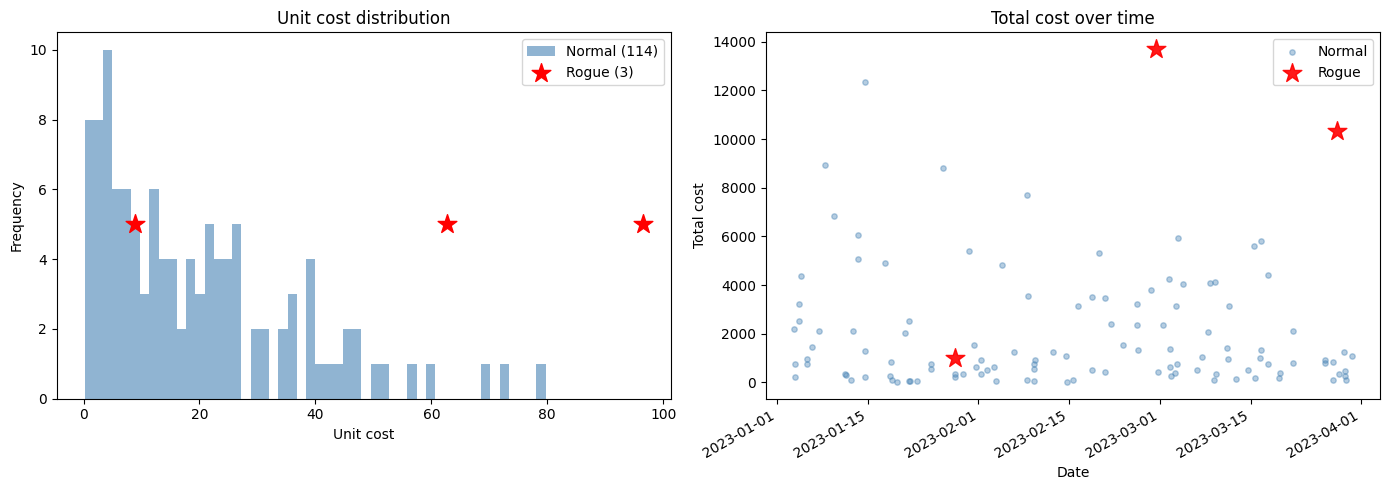

In [ ]:
purchases = tx_df[tx_df['Type'] == 'Purchase'].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: UnitCost distribution
normal_pur = purchases[~purchases['IS_ROGUE']]
rogue_pur = purchases[purchases['IS_ROGUE']]

axes[0].hist(normal_pur['UnitCost'], bins=50, alpha=0.6,
             color='steelblue', label=f'Normal ({len(normal_pur)})')
axes[0].scatter(rogue_pur['UnitCost'],
                [5] * len(rogue_pur), color='red', s=200, marker='*',
                label=f'Rogue ({len(rogue_pur)})', zorder=5)
axes[0].set_xlabel('Unit cost')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Unit cost distribution')
axes[0].legend()

# Panel 2: TotalCost scatter over time
axes[1].scatter(normal_pur['Datetime'], normal_pur['TotalCost'],
                 s=15, alpha=0.4, color='steelblue', label='Normal')
axes[1].scatter(rogue_pur['Datetime'], rogue_pur['TotalCost'],
                 s=200, alpha=0.9, color='red', marker='*', label='Rogue')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Total cost')
axes[1].set_title('Total cost over time')
axes[1].legend()
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

**The rogue transactions are clearly visible** on both univariate measures — unit cost is extreme (≥ 10× the normal mean) and total cost spikes far above normal purchases. A simple z-score detector on `UnitCost` would catch all three.

But that's the easy case. Real simulations can encode *subtle* anomalies — patterns that require:
- **Collective outlier tests** (e.g., "this purchaser never buys product 0")
- **Time-series analysis** (e.g., "spike always on day 28")
- **Contextual tests** (e.g., "quantity trends up log-monthly — nothing else does")

These are exactly what Chapter 12 (collective outliers) and Chapter 17 (time series) cover, and simulations are often the only practical way to **test** those detectors with labeled ground-truth data.

---
## 11.5 Training Classifiers to Distinguish Real from Synthetic

**Real-vs-Fake** and **DML (Distance Metric Learning)** detectors use synthetic data differently: rather than *testing* detectors with it, they *train* on it. A classifier learns to separate real records from synthetic ones; records that the classifier is *uncertain* about are flagged as outliers.

The quality of these detectors depends entirely on the quality and variety of the synthetic training data. The same methods from this chapter — independent, left-to-right, GMM, doping — all apply.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# ── Build training data: real + synthetic (weak correlation) ──
np.random.seed(0)
real_labels = np.ones(len(df))

# Mix of synthetic methods for diversity
synth_a = generate_independent(df.head(500))
synth_b = generate_left_to_right(df.head(500), cols_to_use=2)
synth_all = pd.concat([synth_a, synth_b], ignore_index=True)
synth_labels = np.zeros(len(synth_all))

X = pd.concat([df, synth_all], ignore_index=True)
y = np.concatenate([real_labels, synth_labels])

# Shuffle + split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
                                                      random_state=0, stratify=y)

# Train classifier
clf = RandomForestClassifier(n_estimators=100, max_depth=10,
                              random_state=0, n_jobs=-1)
clf.fit(X_train, y_train)

# Predict probabilities on the full real dataset
real_probs = clf.predict_proba(df)[:, 1]  # P(real)
print(f"Classifier accuracy on test set: {clf.score(X_test, y_test):.3f}")
print(f"\nP(real) for real records:")
print(f"  Mean:   {real_probs.mean():.3f}")
print(f"  Min:    {real_probs.min():.3f}   <-- these are the outliers")
print(f"  Bottom 5 P(real) scores: {np.sort(real_probs)[:5].round(3)}")

Classifier accuracy on test set: 0.962

P(real) for real records:
  Mean:   0.911
  Min:    0.299   <-- these are the outliers
  Bottom 5 P(real) scores: [0.299 0.449 0.453 0.465 0.469]


**How this translates to outlier detection:**

For every real record, the trained classifier outputs `P(real)` — a number between 0 and 1. Real records that the classifier is *unsure* about (low P(real)) are flagged as outliers, because they look "synthetic-like" — they don't fit the pattern of most real records.

The mean P(real) across the real data should be well above 0.5 (the classifier has learned the decision boundary); the **minimum** identifies the most outlier-like real records.

### 11.5.1 Caveats (and Goodhart's Law)

Real-vs-Fake / DML detectors are limited by the synthetic data they were trained on:

1. **Coverage gap**: if your synthetic data doesn't include a certain type of outlier, the detector won't learn to catch it.
2. **Evaluation trap** (*Goodhart's law*): using the same synthetic-data generator to both **train** the detector and **evaluate** it overstates performance. Always evaluate with synthetic data generated by a **different method** than the training data.
3. **Not robust to unknown outliers**: compared to algorithmic detectors (LOF, IF), classifier-based detectors tend to fail on outlier types they weren't trained on.

The solution is to **ensemble**: combine Real-vs-Fake with traditional detectors. Use Real-vs-Fake for types of outliers you know you care about; use LOF/IF to catch unexpected anomalies.

---
## 11.6 Chapter Summary

Synthetic data powers three distinct parts of outlier detection:

1. **Understanding detectors** → 2D toy datasets and realistic synthetic inliers
2. **Tuning and testing** → varied synthetic outliers (new + doped) across multiple difficulty levels
3. **Training classifier-based detectors** → Real-vs-Fake / DML

**Generation methods compared:**

| Method | Preserves correlations | Best for | Speed |
|---|---|---|---|
| Independent histogram | No | Strong/obvious outliers | Fast |
| Left-to-right (RF, all cols) | Yes | Realistic inliers, RvF training | Slow |
| Left-to-right (RF, k cols) | Partially | Medium-realism outliers | Medium |
| GMM (default) | Yes | Realistic inliers | Fast |
| GMM (inflated covariance) | Yes | Graded outliers | Fast |
| Simple doping | N/A | Controlled perturbations | Fast |
| RF doping | N/A | Rare combinations | Slow |
| Simulation | Yes + temporal | Collective/contextual outliers | Slow setup |

**The general principle:** generate a *battery* of synthetic datasets at varying difficulty levels. A single dataset tells you little; a diverse collection reveals exactly which detectors excel at which outlier types.

**Avoid the evaluation trap:** never use the same generator to both train and evaluate a detector. If you trained on RF-generated synthetic data, evaluate on GMM-generated data (or real labelled anomalies, if you have them).

---
## Appendix A — Colab-Only Cells

Cells below require internet access or heavy libraries.

### A.1 Fetching the Real Baseball Dataset from OpenML

The textbook uses the actual OpenML `baseball` dataset. Replace the synthetic dataset we used above with this cell's output to reproduce the textbook's exact results.

In [ ]:
# @title Colab-only: fetch real baseball dataset
import pandas as pd
from sklearn.datasets import fetch_openml

data = fetch_openml('baseball', version=1, parser='auto')
df_real = pd.DataFrame(data.data, columns=data.feature_names)
df_real['Strikeouts'] = df_real['Strikeouts'].fillna(df_real['Strikeouts'].median())

print(f"Shape: {df_real.shape}")
print(df_real.describe())

Shape: (1340, 16)
       Number_seasons  Games_played       At_bats         Runs         Hits  \
count     1340.000000   1340.000000   1340.000000  1340.000000  1340.000000   
mean        13.485821   1331.263433   4534.612687   635.313433  1248.567164   
std          3.136279    519.165125   2094.191124   376.400804   647.664709   
min         10.000000    140.000000    252.000000    20.000000    48.000000   
25%         11.000000    958.750000   2979.500000   355.000000   766.500000   
50%         13.000000   1282.500000   4302.000000   575.000000  1168.000000   
75%         15.000000   1651.500000   5815.250000   843.250000  1613.000000   
max         26.000000   3562.000000  14053.000000  2246.000000  4256.000000   

           Doubles      Triples    Home_runs         RBIs        Walks  \
count  1340.000000  1340.000000  1340.000000  1340.000000  1340.000000   
mean    203.225373    50.811940    85.109701   565.744776   445.584328   
std     116.576053    41.038358    97.930043   3

The real OpenML dataset has ~1340 rows and features like Games_played, At_bats, Runs, Hits, Doubles, Triples, Home_runs, RBIs, Walks, Strikeouts, Batting_average, On_base_pct, Slugging_pct. The correlation between At_bats and RBIs is ~0.94.

### A.2 Faker for Generating Realistic Names/Addresses/IDs

For datasets that include text fields (names, addresses, emails, IP addresses), the `Faker` library generates realistic-looking values.

In [ ]:
# @title Colab-only: Faker example
!pip install -q Faker
from faker import Faker
fake = Faker()
Faker.seed(0)

# Generate 5 fake records
for _ in range(5):
    print({
        'name': fake.name(),
        'email': fake.email(),
        'address': fake.address().replace('\n', ', '),
        'ip': fake.ipv4(),
        'job': fake.job(),
    })

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 23.2 MB/s eta 0:00:00
{'name': 'Norma Fisher', 'email': 'tammy76@example.com', 'address': 'Unit 5938 Box 2421, DPO AP 33335', 'ip': '196.150.125.12', 'job': 'Insurance claims handler'}
{'name': 'Benjamin Jefferson', 'email': 'thomas15@example.com', 'address': '778 Brown Plaza, North Jenniferfurt, VT 88077', 'ip': '159.150.199.159', 'job': 'Lecturer, further education'}
{'name': 'Frederick Harrell', 'email': 'sallywalker@example.org', 'address': '15871 Arnold Squares Apt. 858, Port Carrie, OR 38204', 'ip': '28.81.28.52', 'job': 'Investment analyst'}
{'name': 'Donna Lopez', 'email': 'antoniozavala@example.com', 'address': '220 Rachael Village, Masseyhaven, KY 68893', 'ip': '163.113.118.232', 'job': 'Theme park manager'}
{'name': 'Jennifer Hill', 'email': 'skeller@example.com', 'address': '9533 Jessica Crescent, West Laura, MA 56354', 'ip': '161.156.22.160', 'job': 'Dancer'}


Faker is particularly useful when building simulations that need plausible-looking text fields — staff names, supplier addresses, transaction IDs, etc.

### A.3 Full Year-Long Simulation

The notebook's simulation ran for 3 months with 15-minute steps. The textbook's full simulation runs for 1 year with 1-minute steps, producing ~100K+ transactions. See the full code at:

> `https://mng.bz/lrjj`

The larger dataset is needed for training/testing collective-outlier detectors (Chapter 12) and time-series methods (Chapter 17), which need enough data to establish baseline rhythms.

In [ ]:
# @title Colab-only: full year-long simulation (slow, ~minutes)
from datetime import datetime, timedelta
import pandas as pd
import numpy as np

# Use the same Purchaser / RoguePurchaser / SalesProcess classes from above,
# but run at 1-minute granularity for a full year (plus 2-week burn-in).

start_dt = datetime(2022, 12, 15, 0, 0)   # burn-in start
end_dt   = datetime(2024, 1, 1, 0, 0)
step     = timedelta(minutes=1)
#
# # ... run simulation loop (see textbook Listing 11.6 for full implementation) ...
# #
# # Expected result:
# #   ~150K–200K transactions over the full year
# #   12 rogue transactions (one per month on day 28)
# #   Strong trend (log-monthly quantity increase) in rogue purchases

Running the full simulation produces a much richer dataset for stress-testing detectors, especially those meant to catch patterns that only emerge over many months of operation.